In [42]:
import numpy as np
import torch.nn as nn
import torch
import gymnasium as gym

from torch.distributions import Categorical
import torch.nn.functional as F

In [43]:
training_metadata = torch.load("/Users/derekzhu/Code/BSRL/experiments/curriculum-learning/artifacts/ppo_training_metadata.pth", weights_only=True)
training_metadata.keys()

dict_keys(['configs', 'losses', 'policy_losses', 'value_losses', 'entropies', 'epoch_mean_rewards', 'epoch_mean_policy_loss', 'epoch_mean_value_loss'])

In [44]:
import matplotlib.pyplot as plt

### Per-Epoch Curves: Policy Loss, Value Loss, Mean Return

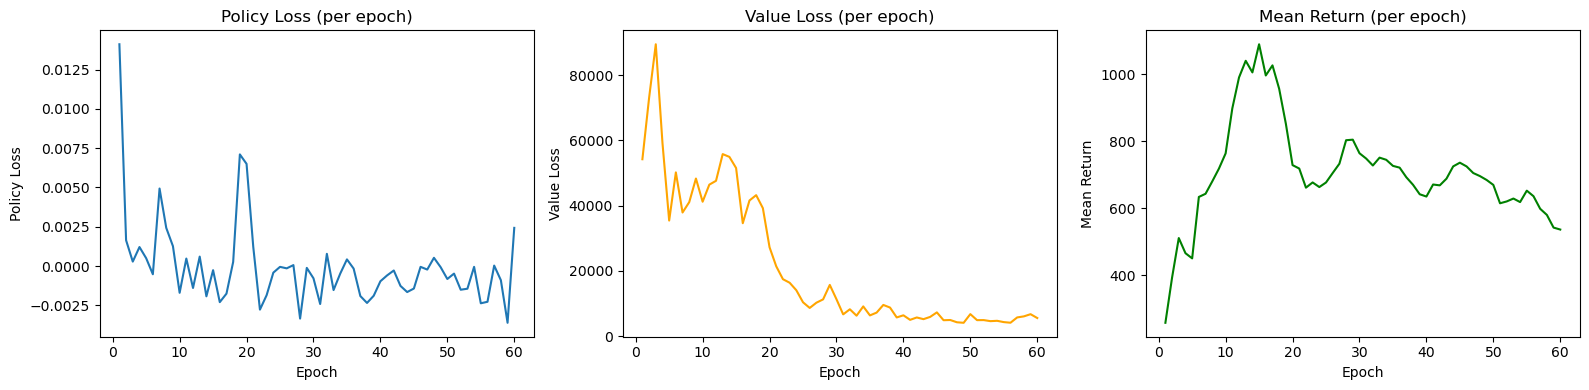

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = range(1, len(training_metadata["epoch_mean_policy_loss"]) + 1)

axes[0].plot(epochs, training_metadata["epoch_mean_policy_loss"])
axes[0].set_title("Policy Loss (per epoch)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Policy Loss")

axes[1].plot(epochs, training_metadata["epoch_mean_value_loss"], color="orange")
axes[1].set_title("Value Loss (per epoch)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value Loss")

axes[2].plot(epochs, training_metadata["epoch_mean_rewards"], color="green")
axes[2].set_title("Mean Return (per epoch)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean Return")

plt.tight_layout()
plt.show()

### Per-Batch Curves: Policy Loss, Value Loss, Entropy

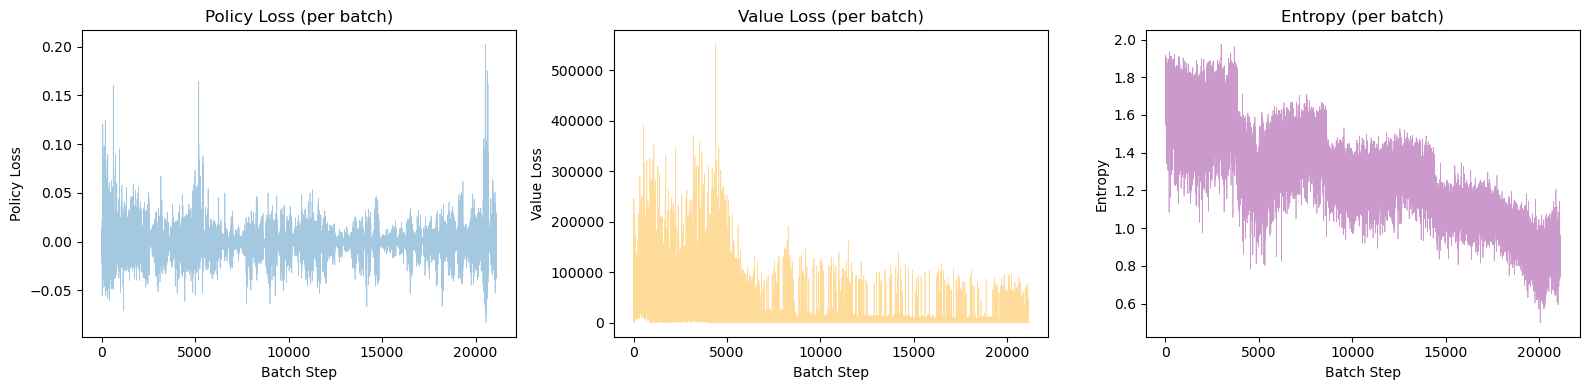

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

steps = range(1, len(training_metadata["policy_losses"]) + 1)

axes[0].plot(steps, training_metadata["policy_losses"], alpha=0.4, linewidth=0.5)
axes[0].set_title("Policy Loss (per batch)")
axes[0].set_xlabel("Batch Step")
axes[0].set_ylabel("Policy Loss")

axes[1].plot(steps, training_metadata["value_losses"], alpha=0.4, linewidth=0.5, color="orange")
axes[1].set_title("Value Loss (per batch)")
axes[1].set_xlabel("Batch Step")
axes[1].set_ylabel("Value Loss")

axes[2].plot(steps, training_metadata["entropies"], alpha=0.4, linewidth=0.5, color="purple")
axes[2].set_title("Entropy (per batch)")
axes[2].set_xlabel("Batch Step")
axes[2].set_ylabel("Entropy")

plt.tight_layout()
plt.show()

### Combined Total Loss (per batch)

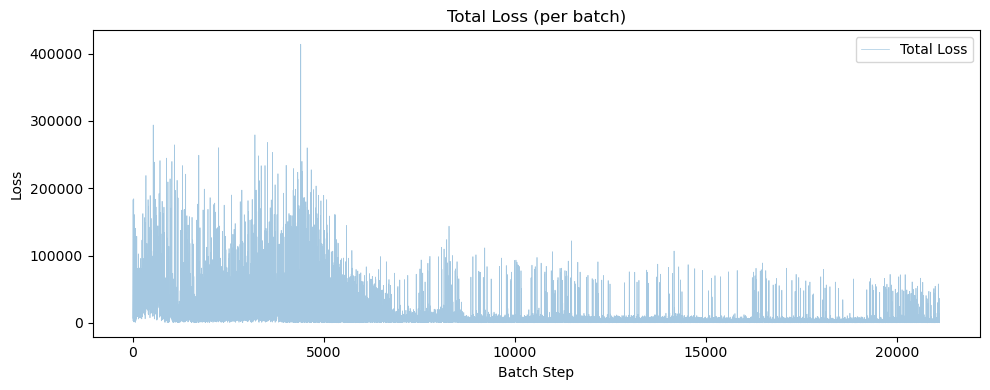

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(training_metadata["losses"], alpha=0.4, linewidth=0.5, label="Total Loss")
plt.title("Total Loss (per batch)")
plt.xlabel("Batch Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()